In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import pickle
import joblib
from scipy.stats import chi2_contingency

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score ,classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
df = pd.read_csv('data_set\\raw.csv')

In [4]:
df.shape

(2067, 16)

In [5]:
df.head()

,Age,Gender,Height,Weight,Waist_Circumference,Diet_Food_Habits,Family_History,Blood_Pressure,Cholesterol_Lipid_Levels,Thirst,Fatigue,Urination,Vision Changes,BMI,DiabetesRisk,RiskLevel
0,24,1,176.96,47.82,27.52,2.06,0,0,0,0,0,0,0,16.37,29.69,0
1,24,1,174.81,52.60,27.51,1.03,0,0,0,0,0,0,1,18.43,31.04,1
2,28,0,162.11,45.91,25.67,5.17,0,0,0,0,0,0,0,18.71,28.55,0
3,24,0,172.70,53.55,28.43,4.13,0,1,0,0,0,0,1,19.22,36.28,1
4,22,0,163.18,44.00,25.68,5.18,0,0,0,0,0,0,0,17.69,24.35,0


In [6]:
df.tail()

,Age,Gender,Height,Weight,Waist_Circumference,Diet_Food_Habits,Family_History,Blood_Pressure,Cholesterol_Lipid_Levels,Thirst,Fatigue,Urination,Vision Changes,BMI,DiabetesRisk,RiskLevel
2062,48,0,156.77,108.48,31.19,9.27,0,1,1,0,0,0,1,42.18,67.35,1
2063,41,0,181.26,114.74,37.03,6.16,0,0,1,0,0,0,0,33.37,73.86,2
2064,44,1,172.44,94.91,32.15,10.28,0,0,0,0,0,0,1,30.49,59.81,1
2065,42,1,174.39,89.01,31.20,3.10,0,0,0,0,0,0,0,27.95,51.86,1
2066,45,1,173.42,87.84,34.12,6.16,0,0,0,0,0,0,0,27.92,63.36,1


In [7]:
df.drop(['DiabetesRisk'], axis=1, inplace=True)

In [8]:
df.columns

Index(['Age', 'Gender', 'Height', 'Weight', 'Waist_Circumference',
       'Diet_Food_Habits', 'Family_History', 'Blood_Pressure',
       'Cholesterol_Lipid_Levels', 'Thirst', 'Fatigue', 'Urination',
       'Vision Changes', 'BMI', 'RiskLevel'],
      dtype='object')

In [9]:
cl = ['Age', 'Gender', 'Height', 'Weight', 'Waist_Circumference',
       'Diet_Food_Habits', 'Family_History', 'Blood_Pressure',
       'Cholesterol_Lipid_Levels', 'Thirst', 'Fatigue', 'Urination',
       'Vision Changes', 'BMI', 'RiskLevel']

In [10]:
for i in cl:
    print(f'{i}: {df[i].unique()}')

Age: [24 28 22 25 26 23 20 21 27 29 30 31 39 32 37 34 33 36 35 38 44 40 41 43
 48 47 46 42 45 49]
Gender: [1 0]
Height: [176.96 174.81 162.11 172.7  163.18 170.07 166.84 169.53 173.76 185.41
 168.49 153.85 183.28 164.23 172.69 180.11 158.92 174.82 174.83 186.47
 163.17 190.72 176.94 180.1  158.95 158.91 185.38 185.39 169.51 152.59
 163.16 183.29 166.35 187.19 170.58 171.63 182.22 181.18 175.9  164.21
 180.12 180.76 166.31 186.46 183.31 182.24 184.34 184.36 190.7  176.92
 193.88 190.71 185.4  169.52 185.42 185.43 168.47 161.04 187.52 162.1
 182.23 159.99 171.15 178.   184.33 177.98 184.37 196.01 177.99 191.79
 191.77 176.93 179.06 191.76 173.77 179.58 180.08 172.71 173.75 176.95
 158.93 174.8  174.79 163.15 179.05 168.46 183.32 164.22 180.13 158.94
 166.37 186.5  159.98 180.74 166.36 184.35 189.66 171.33 175.88 191.24
 180.75 166.34 180.42 181.17 190.73 164.24 152.55 183.3  187.23 174.84
 181.16 175.89 180.73 175.35 182.25 176.2  156.87 154.98 143.71 153.11
 144.64 150.76 147.92 150.28 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2067 entries, 0 to 2066
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2067 non-null   int64  
 1   Gender                    2067 non-null   int64  
 2   Height                    2067 non-null   float64
 3   Weight                    2067 non-null   float64
 4   Waist_Circumference       2067 non-null   float64
 5   Diet_Food_Habits          2067 non-null   float64
 6   Family_History            2067 non-null   int64  
 7   Blood_Pressure            2067 non-null   int64  
 8   Cholesterol_Lipid_Levels  2067 non-null   int64  
 9   Thirst                    2067 non-null   int64  
 10  Fatigue                   2067 non-null   int64  
 11  Urination                 2067 non-null   int64  
 12  Vision Changes            2067 non-null   int64  
 13  BMI                       2067 non-null   float64
 14  RiskLeve

In [12]:
df.describe()

,Age,Gender,Height,Weight,Waist_Circumference,Diet_Food_Habits,Family_History,Blood_Pressure,Cholesterol_Lipid_Levels,Thirst,Fatigue,Urination,Vision Changes,BMI,RiskLevel
count,2067.000000,2067.000000,2067.000000,2067.000000,2067.000000,2067.000000,2067.0,2067.000000,2067.000000,2067.0,2067.0,2067.0,2067.000000,2067.000000,2067.000000
mean,33.699565,0.576197,169.024775,73.801364,33.899303,4.766130,0.0,0.362845,0.330914,0.0,0.0,0.0,0.435414,25.938452,1.015965
std,8.507056,0.494279,14.187360,16.790988,7.953074,2.372192,0.0,0.480937,0.470656,0.0,0.0,0.0,0.495931,6.731525,0.435853
min,20.000000,0.000000,135.250000,32.520000,18.340000,0.890000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,13.070000,0.000000
25%,26.000000,0.000000,158.365000,61.195000,31.190000,3.045000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,20.965000,1.000000
50%,33.000000,1.000000,167.580000,73.210000,33.140000,4.550000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,25.280000,1.000000
75%,41.000000,1.000000,179.625000,85.500000,35.800000,6.370000,0.0,1.000000,1.000000,0.0,0.0,0.0,1.000000,29.650000,1.000000
max,49.000000,1.000000,207.080000,157.490000,113.780000,10.890000,0.0,1.000000,1.000000,0.0,0.0,0.0,1.000000,69.900000,2.000000


([0, 1, 2], [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2')])

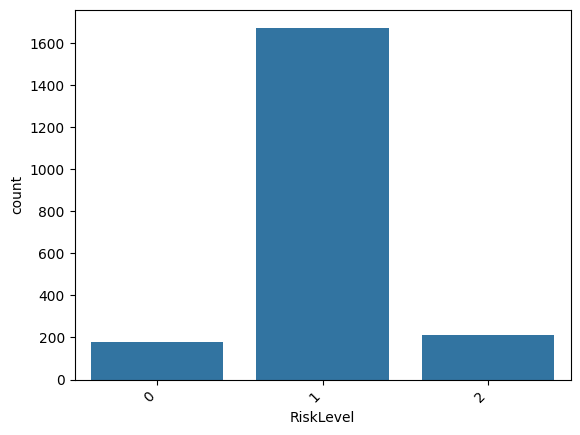

In [13]:
sns.countplot(x='RiskLevel',data=df)
plt.xticks(rotation=45, ha='right')

In [14]:
df.columns

Index(['Age', 'Gender', 'Height', 'Weight', 'Waist_Circumference',
       'Diet_Food_Habits', 'Family_History', 'Blood_Pressure',
       'Cholesterol_Lipid_Levels', 'Thirst', 'Fatigue', 'Urination',
       'Vision Changes', 'BMI', 'RiskLevel'],
      dtype='object')

([0, 1, 2], [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2')])

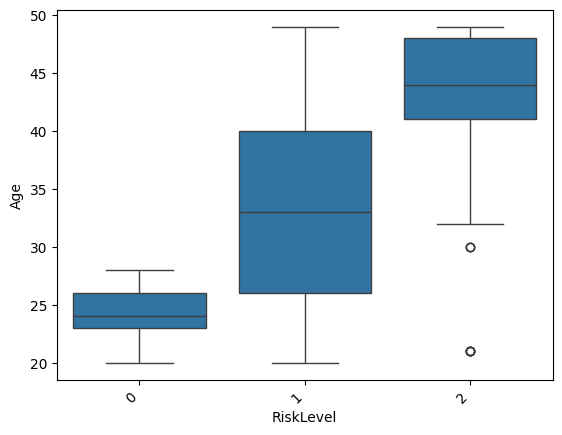

In [15]:
sns.boxplot(x='RiskLevel',y='Age',data=df)
plt.xticks(rotation=45, ha='right')

In [16]:
cols = ['Age', 'Height', 'Weight', 'Waist_Circumference', 'BMI']

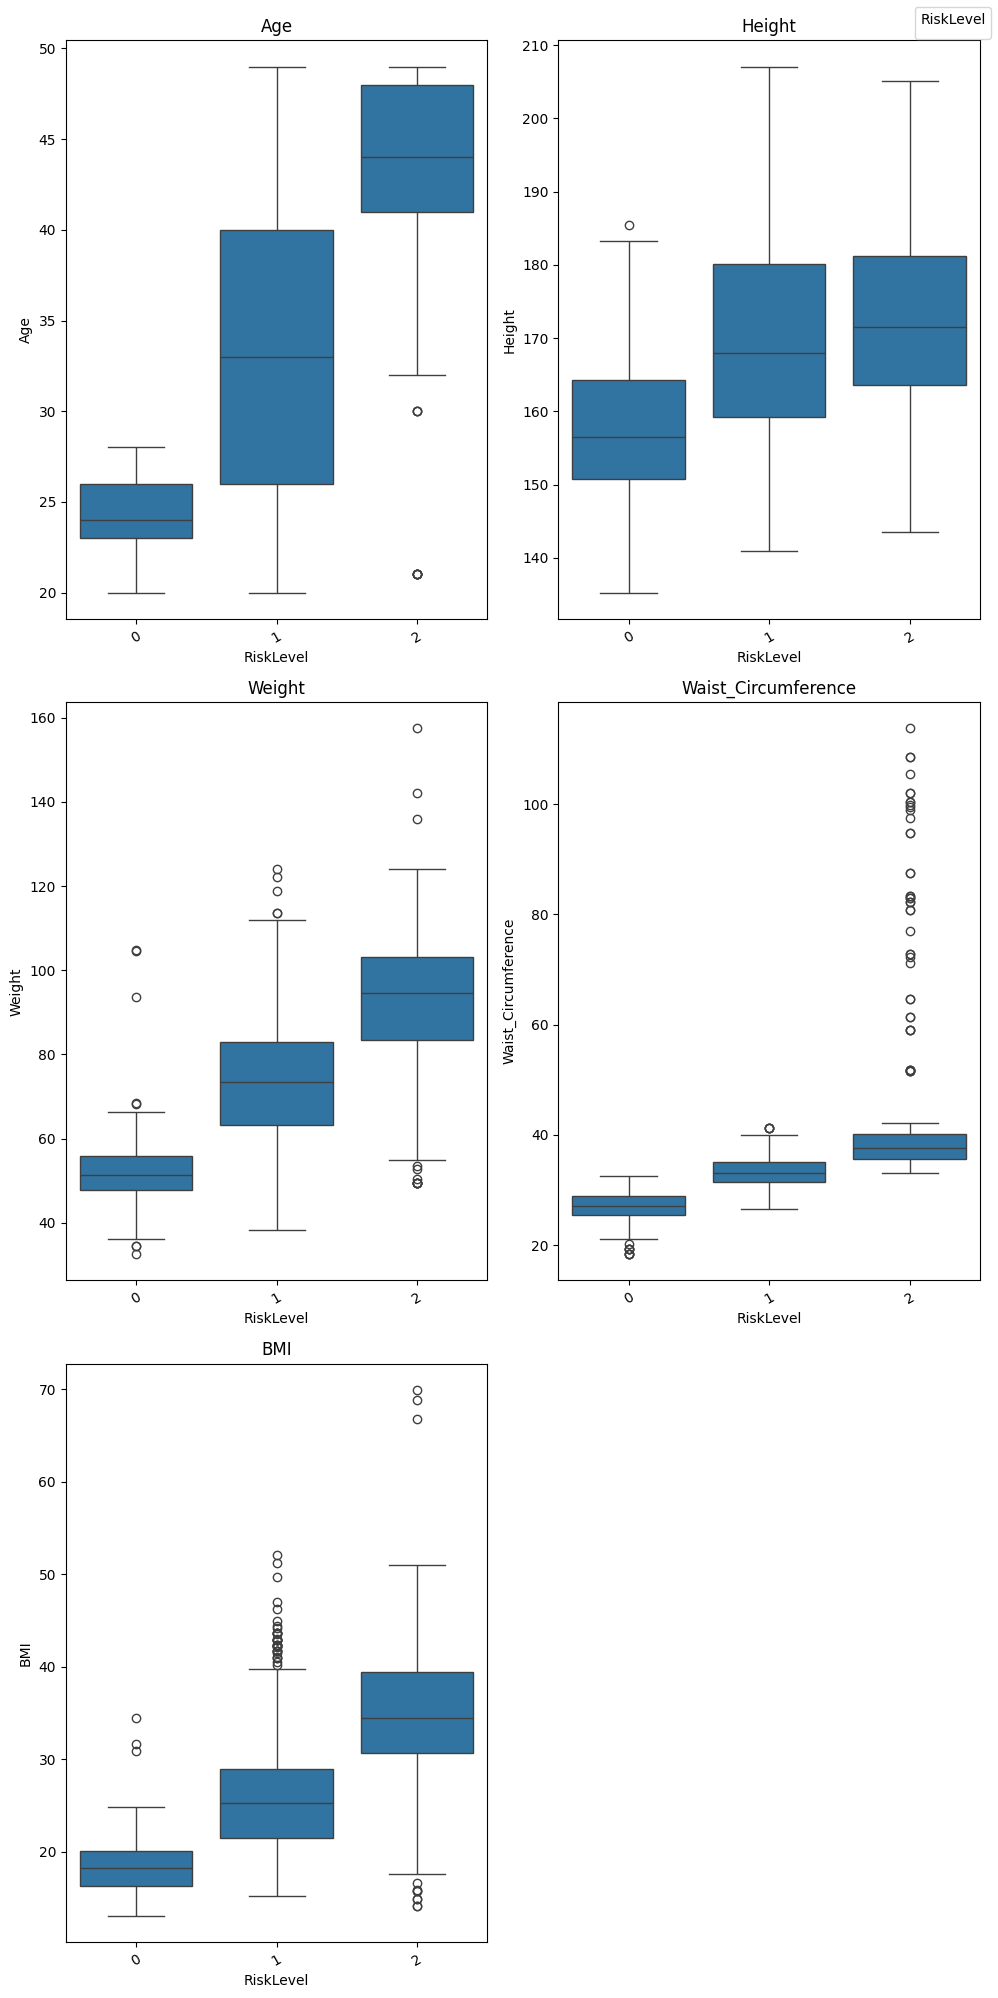

In [17]:

plt.figure(figsize=(10, 20))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols)//2 + 1, 2, i)  
    # sns.countplot(x=col, data=df, hue='class')
    sns.boxplot(x='RiskLevel',y=col,data=df)
    plt.title(col)
    plt.xticks(rotation=30)
    plt.legend([], [], frameon=False) 

handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, title='RiskLevel', loc='upper right')

plt.tight_layout()
plt.show()

In [18]:
numeric_features = ['Age', 'Height', 'Weight', 'Waist_Circumference', 'BMI']

In [19]:
df.columns

Index(['Age', 'Gender', 'Height', 'Weight', 'Waist_Circumference',
       'Diet_Food_Habits', 'Family_History', 'Blood_Pressure',
       'Cholesterol_Lipid_Levels', 'Thirst', 'Fatigue', 'Urination',
       'Vision Changes', 'BMI', 'RiskLevel'],
      dtype='object')

In [20]:
categorical_features = ['Gender', 'Diet_Food_Habits', 'Blood_Pressure', 'Family_History', 'Cholesterol_Lipid_Levels', 'Thirst', 'Fatigue', 'Urination', 'Vision Changes']

In [21]:
def cramers_v_and_p(matrix):
    chi2, p, _, _ = chi2_contingency(matrix)
    n = matrix.sum().sum()
    r, k = matrix.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return cramers_v, p

In [22]:
results = []

for features in categorical_features:

    matrix = pd.crosstab(df[features], df['RiskLevel'])
    
    cv, p_value = cramers_v_and_p(matrix)
    results.append((features, cv, p_value))

In [23]:
results_df = pd.DataFrame(results, columns=['categorical features', 'Cramér\'s V', 'p-value'])

In [24]:
results_df['Significant'] = results_df['p-value'] < 0.05

In [25]:
results_df

,categorical features,Cramér's V,p-value,Significant
0,Gender,0.100170,3.135080e-05,True
1,Diet_Food_Habits,0.475487,1.248436e-17,True
2,Blood_Pressure,0.240110,1.327413e-26,True
3,Family_History,NaN,1.000000e+00,False
4,Cholesterol_Lipid_Levels,0.273325,2.940850e-34,True
5,Thirst,NaN,1.000000e+00,False
6,Fatigue,NaN,1.000000e+00,False
7,Urination,NaN,1.000000e+00,False
8,Vision Changes,0.126492,6.583103e-08,True


In [26]:
df.drop(['Family_History', 'Thirst', 'Fatigue', 'Urination'], axis=1, inplace=True)

In [27]:
df.columns

Index(['Age', 'Gender', 'Height', 'Weight', 'Waist_Circumference',
       'Diet_Food_Habits', 'Blood_Pressure', 'Cholesterol_Lipid_Levels',
       'Vision Changes', 'BMI', 'RiskLevel'],
      dtype='object')

In [28]:
categorical_features = ['Gender', 'Diet_Food_Habits', 'Blood_Pressure', 'Cholesterol_Lipid_Levels', 'Vision Changes']

In [29]:
corr_for_numerical = df.drop(categorical_features, axis=1).corr()
corr_for_numerical

,Age,Height,Weight,Waist_Circumference,BMI,RiskLevel
Age,1.000000,0.350457,0.498268,0.250298,0.587168,0.488869
Height,0.350457,1.000000,0.217967,0.015282,0.034723,0.201888
Weight,0.498268,0.217967,1.000000,0.269566,0.826309,0.520054
Waist_Circumference,0.250298,0.015282,0.269566,1.000000,0.248066,0.520556
BMI,0.587168,0.034723,0.826309,0.248066,1.000000,0.528779
RiskLevel,0.488869,0.201888,0.520054,0.520556,0.528779,1.000000


In [30]:
corr_for_numerical["RiskLevel"]

Age                    0.488869
Height                 0.201888
Weight                 0.520054
Waist_Circumference    0.520556
BMI                    0.528779
RiskLevel              1.000000
Name: RiskLevel, dtype: float64

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Age'),
  Text(1, 0, 'Height'),
  Text(2, 0, 'Weight'),
  Text(3, 0, 'Waist_Circumference'),
  Text(4, 0, 'BMI'),
  Text(5, 0, 'RiskLevel')])

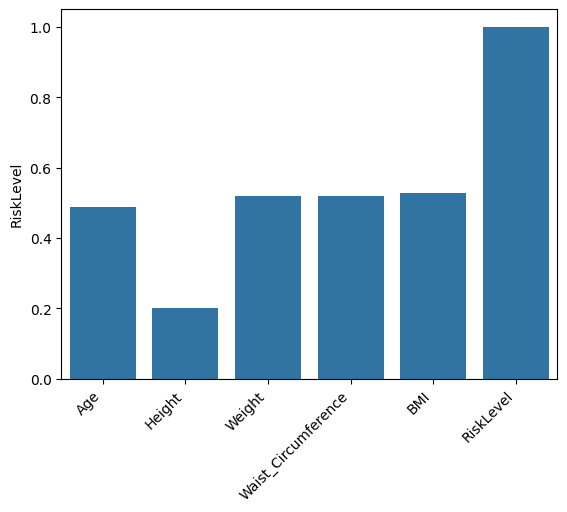

In [31]:
sns.barplot( data=corr_for_numerical["RiskLevel"] )
plt.xticks(rotation=45, ha='right')

In [32]:
df.columns

Index(['Age', 'Gender', 'Height', 'Weight', 'Waist_Circumference',
       'Diet_Food_Habits', 'Blood_Pressure', 'Cholesterol_Lipid_Levels',
       'Vision Changes', 'BMI', 'RiskLevel'],
      dtype='object')

In [33]:
df.head()

,Age,Gender,Height,Weight,Waist_Circumference,Diet_Food_Habits,Blood_Pressure,Cholesterol_Lipid_Levels,Vision Changes,BMI,RiskLevel
0,24,1,176.96,47.82,27.52,2.06,0,0,0,16.37,0
1,24,1,174.81,52.60,27.51,1.03,0,0,1,18.43,1
2,28,0,162.11,45.91,25.67,5.17,0,0,0,18.71,0
3,24,0,172.70,53.55,28.43,4.13,1,0,1,19.22,1
4,22,0,163.18,44.00,25.68,5.18,0,0,0,17.69,0


In [34]:
df.isnull().sum()

Age                         0
Gender                      0
Height                      0
Weight                      0
Waist_Circumference         0
Diet_Food_Habits            0
Blood_Pressure              0
Cholesterol_Lipid_Levels    0
Vision Changes              0
BMI                         0
RiskLevel                   0
dtype: int64

In [35]:
X = df.drop("RiskLevel", axis=1)
y = df["RiskLevel"]

In [36]:
num_features = X.select_dtypes(exclude="object").columns
num_features

Index(['Age', 'Gender', 'Height', 'Weight', 'Waist_Circumference',
       'Diet_Food_Habits', 'Blood_Pressure', 'Cholesterol_Lipid_Levels',
       'Vision Changes', 'BMI'],
      dtype='object')

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [38]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

In [39]:
def evaluate_model(name, model):
    pipe = Pipeline(steps=[
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test) 

    acc = accuracy_score(y_test, y_pred)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted"  
    )

    auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr", 
        average="weighted"
    )

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    }


In [40]:
results = []

for name, model in models.items():
    metrics = evaluate_model(name, model)
    results.append(metrics)

In [41]:
results_df = pd.DataFrame(results).sort_values(
    by="Accuracy", ascending=False
)

In [42]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,XGBoost,0.985507,0.985719,0.985507,0.985577,0.996750
3,Gradient Boosting,0.978261,0.978272,0.978261,0.978005,0.995837
2,Random Forest,0.973430,0.973453,0.973430,0.972853,0.995467
0,Logistic Regression,0.932367,0.930399,0.932367,0.930833,0.976015
4,KNN,0.932367,0.932440,0.932367,0.932330,0.968836
1,SVM (RBF),0.823671,0.768264,0.823671,0.755113,0.964901


In [43]:
best_pipe = Pipeline(steps=[
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

In [44]:
best_pipe.fit(X_train, y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [45]:
y_pred = best_pipe.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("XGBoost_Accuracy:", accuracy*100)

print(classification_report(y_test, y_pred))

XGBoost_Accuracy: 98.55072463768117
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.99      0.99      0.99       335
           2       0.95      0.98      0.97        43

    accuracy                           0.99       414
   macro avg       0.96      0.98      0.97       414
weighted avg       0.99      0.99      0.99       414



In [46]:
classes = ['stage_1', 'stage_2', 'stage_3']

def plot_confusion_matrix(y_true, y_pred, classes, figsize=(6, 4), cmap=plt.cm.Blues):

    cm = confusion_matrix(y_true, y_pred) 
    
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, cmap=cmap, fmt=".2f", xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.show()

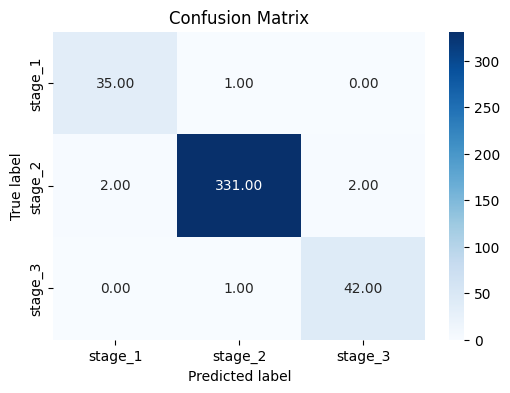

In [47]:
plot_confusion_matrix(y_test, y_pred, classes)

In [48]:
# joblib.dump(best_pipe, "final_model.pkl")

### Testing

In [49]:
true_label = {0: 'stage_1', 1: 'stage_2', 2: 'stage_3'}

In [50]:
loaded_model = joblib.load("final_model.pkl")

In [51]:
y_test

1434    2
1557    1
1442    1
1497    1
1832    2
       ..
1416    1
495     0
613     1
1076    1
1869    2
Name: RiskLevel, Length: 414, dtype: int64

In [52]:
X_test[10:11]

,Age,Gender,Height,Weight,Waist_Circumference,Diet_Food_Habits,Blood_Pressure,Cholesterol_Lipid_Levels,Vision Changes,BMI
675,23,1,151.69,78.05,28.99,5.09,1,0,1,28.94


In [53]:
y_pred = loaded_model.predict(X_test[10:11])
y_pred[0]

np.int64(1)

In [54]:
print("True Label:",true_label[y_test.iloc[10]])

print("Predicted Label:", true_label[(y_pred[0])])

True Label: stage_2
Predicted Label: stage_2


In [55]:
X_test[0:1]

,Age,Gender,Height,Weight,Waist_Circumference,Diet_Food_Habits,Blood_Pressure,Cholesterol_Lipid_Levels,Vision Changes,BMI
1434,48,0,194.33,93.18,35.65,7.26,0,0,0,30.77


In [56]:
y_pred = loaded_model.predict(X_test[0:1])
y_pred

array([2])

In [57]:
print("True Label:",true_label[(y_test.iloc[0])])

print("Predicted Label:", true_label[(y_pred[0])])

True Label: stage_3
Predicted Label: stage_3


In [58]:
data = {
    "Age": 48,
    "Gender": 0,
    "Height": 194.33,
    "Weight": 93.18,
    "Waist_Circumference": 35.65,
    "Diet_Food_Habits": 7.26,
    "Blood_Pressure": 0,
    "Cholesterol_Lipid_Levels": 0,
    "Vision Changes": 0,
    "BMI": 30.77
}
df_new = pd.DataFrame([data])
df_new

,Age,Gender,Height,Weight,Waist_Circumference,Diet_Food_Habits,Blood_Pressure,Cholesterol_Lipid_Levels,Vision Changes,BMI
0,48,0,194.33,93.18,35.65,7.26,0,0,0,30.77


In [59]:
y_pred = loaded_model.predict(df_new)
# print(y_pred)
print("Predicted Label:", true_label[(y_pred[0])])

Predicted Label: stage_3
